<a href="https://colab.research.google.com/github/NehaSontakk/KEGG_GRAPH/blob/main/KO_graph_generation_from_expression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this script

1.   Load a KO Expression from the API
2.   Generate a graph from it
3.   Create a node list, adjacency list for original graph
4.   Store this graph object/ adjacency list



In [ ]:
!pip install bioservices
!apt-get install graphviz libgraphviz-dev
!pip install pygraphviz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 726.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.0/258.0 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.3/145.3 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.2/750.2 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.8/259.8 kB 10.3 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently t

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from bioservices import KEGG
import re
import pandas as pd
import sys


In [ ]:
graph_storage_directory = "/content/drive/MyDrive/Lab Work/KEGG_KO_Graphs/KEGG_Graph_Storage/"

In [ ]:
#Gather KO definitions
def fetch_and_plot_reactions(module_id):
    kegg = KEGG()
    try:
        module_info = kegg.get(module_id)
        print(module_info)
        module_parsed = kegg.parse(module_info)
        print(module_parsed)
    except Exception as e:
        print(f"Failed to retrieve or parse module: {e}")
        return None

    reactions = module_parsed.get("REACTION", {})
    orthology = module_parsed.get("ORTHOLOGY", {})
    compounds = module_parsed.get("COMPOUND",{})
    definition = module_parsed.get("DEFINITION",{})
    if not reactions:
        print("No reactions found in the module.")
        return None

    return reactions,orthology,compounds,definition

#reactions,orthology,compounds,definition = fetch_and_plot_reactions(module_id)
#fetch_and_plot_reactions(module_id)

In [ ]:
#Building the node class
class Node:
    node_counter = 1  # Class variable for unique node IDs

    def __init__(self, name):
        self.name = name
        self.id = Node.node_counter
        Node.node_counter += 1
        self.visited = False
        self.children = []

    def __repr__(self):
        return f"{self.id}_{self.name}"

    # Implement equality and hashing based on the unique id
    def __eq__(self, other):
        return isinstance(other, Node) and self.id == other.id

    def __hash__(self):
        return hash(self.id)



In [ ]:
# Global variables
nodes = []   # List of all Node objects
edges = []   # List of edges as tuples (from_node, to_node)
tokens = []
current_token_index = 0
indent_level = 0  # For tracking indentation in print statements

In [ ]:
#Helper functions to create nodes and edges
def create_node(name):
    node = Node(name)
    nodes.append(node)
    return node

def create_edges(from_nodes, to_nodes):
    for from_node in from_nodes:
        for to_node in to_nodes:
            if from_node != to_node and (from_node, to_node) not in edges:
                edges.append((from_node, to_node))
                print(f"Added edge: {from_node} -> {to_node}")

In [ ]:
#Tokenizing function for the input
def tokenize(input_string):
    tokens = []
    i = 0
    input_string = input_string.replace("-- ", "")
    while i < len(input_string):
        c = input_string[i]
        if c.isalnum():
            start = i
            while i < len(input_string) and input_string[i].isalnum():
                i += 1
            tokens.append(input_string[start:i])
        elif c in "-+,() ":
            tokens.append(c)
            i += 1
        else:
            i += 1
    return tokens

In [ ]:
#Helper functions
def current_token():
    if current_token_index < len(tokens):
        return tokens[current_token_index]
    else:
        return None

def match(token_value):
    global current_token_index
    if current_token() == token_value:
        current_token_index += 1
        return True
    else:
        return False

def expect(token_value):
    if match(token_value):
        return True
    else:
        raise Exception(f"Expected '{token_value}' but found '{current_token()}'")

def consume_token():
    global current_token_index
    current_token_index += 1

In [ ]:
#Recursive parsing functions
def parse_expr():
    #Step 1
    #Gather all the space seperated steps in the expression
    global indent_level
    print('  ' * indent_level + f'Entering parse_expr at token: {current_token()}')
    indent_level += 1
    top_nodes, last_nodes = parse_sum_expr()
    while match(" "):
        print('  ' * indent_level + f'Matched space, current token: {current_token()}')
        next_top_nodes, next_last_nodes = parse_sum_expr()
        create_edges(last_nodes, next_top_nodes)
        print('  ' * indent_level + f'Created edges from {last_nodes} to {next_top_nodes}')
        last_nodes = next_last_nodes
    indent_level -= 1
    print('  ' * indent_level + f'Exiting parse_expr with top_nodes: {top_nodes}, last_nodes: {last_nodes}')
    return top_nodes, last_nodes

def parse_sum_expr():
    #Step 2
    #Gather all the comma seperated steps in the expression
    global indent_level
    print('  ' * indent_level + f'Entering parse_sum_expr at token: {current_token()}')
    indent_level += 1
    top_nodes, last_nodes = parse_mult_expr()
    while match(","):
        print('  ' * indent_level + f'Matched ",", current token: {current_token()}')
        next_top_nodes, next_last_nodes = parse_mult_expr()
        top_nodes.extend(next_top_nodes)
        last_nodes.extend(next_last_nodes)
        print('  ' * indent_level + f'Combined top_nodes: {top_nodes}, last_nodes: {last_nodes}')
    indent_level -= 1
    print('  ' * indent_level + f'Exiting parse_sum_expr with top_nodes: {top_nodes}, last_nodes: {last_nodes}')
    return top_nodes, last_nodes

def parse_mult_expr():
    #Step 3
    #Gather all the + or - operations and process seperately
    global indent_level
    print('  ' * indent_level + f'Entering parse_mult_expr at token: {current_token()}')
    indent_level += 1
    top_nodes, last_nodes = parse_factor()

    # Initialize chain_nodes with last_nodes
    chain_nodes = last_nodes.copy()

    while True:
        operator = None
        if match("+"):
            operator = "+"
        elif match("-"):
            operator = "-"
        else:
            break  # Exit loop if neither "+" nor "-" matches

        print('  ' * indent_level + f'Matched "{operator}", current token: {current_token()}')

        # Parse the next expression
        next_top_nodes, next_last_nodes = parse_mult_expr()

        if operator == "+":
            # "+" operator implies a direct sequence
            create_edges(last_nodes, next_top_nodes)
            print(f'Created sequential edges from {last_nodes} to {next_top_nodes}')
            # Update last_nodes
            last_nodes = next_last_nodes
            # Reset chain_nodes to last_nodes
            chain_nodes = last_nodes.copy()
        elif operator == "-":
            # "-" operator implies branching
            # Create branching edges from all nodes in chain_nodes to next_top_nodes
            create_edges(chain_nodes, next_top_nodes)
            print(f'Created branching edges from {chain_nodes} to {next_top_nodes}')
            # Create additional branching edges from last_nodes to next_top_nodes
            create_edges(last_nodes, next_top_nodes)
            print(f'Created additional branching edges from {last_nodes} to {next_top_nodes}')
            # Accumulate chain_nodes with next_last_nodes
            chain_nodes.extend(next_last_nodes)
            # Update last_nodes
            last_nodes = next_last_nodes

    # After loop, connect each node in chain_nodes to all nodes after it
    if chain_nodes and len(chain_nodes) > 1:
        for i in range(len(chain_nodes)):
            from_node = chain_nodes[i]
            targets = chain_nodes[i+1:]
            create_edges([from_node], targets)
            print(f'Created edges from {from_node} to {targets}')

    # Set last_nodes to chain_nodes to include all chain nodes
    last_nodes = chain_nodes.copy()

    indent_level -= 1
    print('  ' * indent_level + f'Exiting parse_mult_expr with top_nodes: {top_nodes}, last_nodes: {last_nodes}')
    return top_nodes, last_nodes

def parse_factor():
    #Step 4
    #Fianl step to process the alphanumeric nodes
    global indent_level
    print('  ' * indent_level + f'Entering parse_factor at token: {current_token()}')
    indent_level += 1
    if match("("):
        print('  ' * indent_level + f'Matched "(", current token: {current_token()}')
        top_nodes, last_nodes = parse_expr()
        expect(")")
        print('  ' * indent_level + f'Expecting ")", current token: {current_token()}')
    elif current_token() is not None and current_token()[0].isalnum():
        token_name = current_token()
        print('  ' * indent_level + f'Creating node for token: {token_name}')
        consume_token()
        node = create_node(token_name)
        top_nodes = [node]
        last_nodes = [node]
    else:
        raise Exception(f"Unexpected token: {current_token()}")
    indent_level -= 1
    print('  ' * indent_level + f'Exiting parse_factor with top_nodes: {top_nodes}, last_nodes: {last_nodes}')
    return top_nodes, last_nodes

In [ ]:
#Function to build the actual graph
#Add source and sink nodes

def generate_graph(nodes, edges):
    G = nx.DiGraph()
    for node in nodes:
        G.add_node(str(node))
    for edge in edges:
        if len(edge) == 3:
            from_node, to_node, label = edge
            G.add_edge(str(from_node), str(to_node), label=label)
        else:
            from_node, to_node = edge
            G.add_edge(str(from_node), str(to_node))
    return G

def build_graph(input_string):
    global tokens, current_token_index, nodes, edges, indent_level
    tokens = tokenize(input_string)
    current_token_index = 0
    nodes = []
    edges = []
    indent_level = 0
    parse_expr()

    # Add "source" and "sink" nodes
    source_node = Node("source")
    sink_node = Node("sink")
    nodes.extend([source_node, sink_node])

    # Determine nodes with no incoming edges
    node_incoming = {node: 0 for node in nodes}
    node_outgoing = {node: 0 for node in nodes}
    for from_node, to_node in edges:
        node_incoming[to_node] = node_incoming.get(to_node, 0) + 1
        node_outgoing[from_node] = node_outgoing.get(from_node, 0) + 1

    # Add edges from "source" to nodes with no incoming edges
    for node in nodes:
        if node_incoming.get(node, 0) == 0 and node != source_node and node != sink_node:
            edges.append((source_node, node))

    # Add edges from nodes with no outgoing edges to "sink"
    for node in nodes:
        if node_outgoing.get(node, 0) == 0 and node != source_node and node != sink_node:
            edges.append((node, sink_node))

    return nodes, edges

In [ ]:
#Represent
def visualize_graph(G,module_id):
    pos = nx.nx_pydot.graphviz_layout(G, prog='dot')

    plt.figure(figsize=(12,12))
    nx.draw(G, pos, with_labels=True, node_size=400, node_color='lightblue', arrows=True, arrowstyle='->', arrowsize=20)

    # Draw edge labels if any
    edge_labels = nx.get_edge_attributes(G, 'label')
    if edge_labels:
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    plt.title("Directed Graph of Module "+str(module_id))
    plt.axis('off')
    plt.show()

In [ ]:
import os
import json
import pickle

def save_graph_and_adjacency_list(G, module_id, storage_directory="graph_storage/"):
    # Create the directory if it doesn't exist
    if not os.path.exists(storage_directory):
        os.makedirs(storage_directory)

    # Define file paths
    graph_path = f"{storage_directory}{module_id}_graph.pkl"
    adjacency_list_path = f"{storage_directory}{module_id}_adjacency_list.json"

    # Check if files already exist
    if os.path.exists(graph_path) and os.path.exists(adjacency_list_path):
        print(f"Files for module {module_id} already exist. Skipping save.")
        return

    # Save the graph object as a pickle file
    with open(graph_path, "wb") as f:
        pickle.dump(G, f)

    # Save the adjacency list as JSON
    adjacency_list = nx.to_dict_of_lists(G)
    with open(adjacency_list_path, "w") as f:
        json.dump(adjacency_list, f)

    print(f"Graph and adjacency list for {module_id} saved in {storage_directory}")



Enter the module IDs separated by commas: M00001
Received module IDs: ['M00001']

Processing module: M00001
Creating directory /root/.cache/bioservices 
Welcome to Bioservices
It looks like you do not have a configuration file.
We are creating one with default values in /root/.config/bioservices/bioservices.cfg .
Done
ENTRY       M00001            Pathway   Module
NAME        Glycolysis (Embden-Meyerhof pathway), glucose => pyruvate
DEFINITION  (K00844,K12407,K00845,K25026,K00886,K08074,K00918) (K01810,K06859,K13810,K15916) (K00850,K16370,K21071,K24182,K00918) (K01623,K01624,K11645,K16305,K16306) K01803 ((K00134,K00150) K00927,K11389) (K01834,K15633,K15634,K15635) (K01689,K27394) (K00873,K12406)
ORTHOLOGY   K00844,K12407,K00845,K25026  hexokinase/glucokinase [EC:2.7.1.1 2.7.1.2] [RN:R01786]
            K00886  polyphosphate glucokinase [EC:2.7.1.63] [RN:R02189]
            K08074,K00918  ADP-dependent glucokinase [EC:2.7.1.147] [RN:R09085]
            K01810,K06859,K13810,K15916  gluco

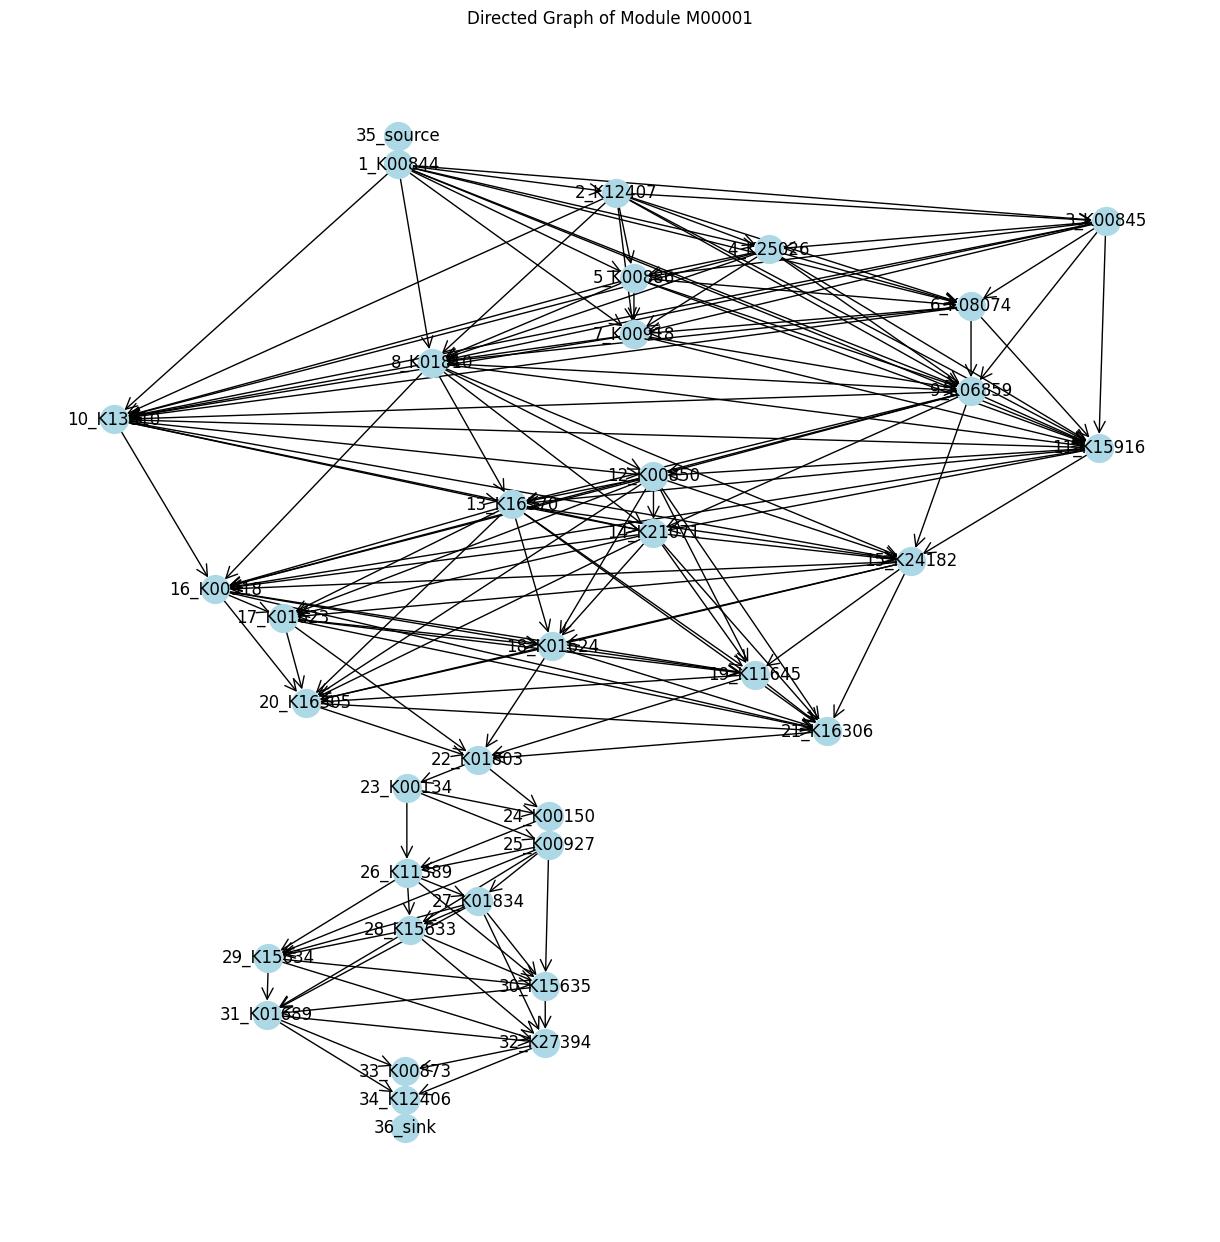

Graph and adjacency list for M00001 saved in /content/drive/MyDrive/Lab Work/KEGG_KO_Graphs/KEGG_Graph_Storage/
Graph and adjacency list saved.

Graph Nodes: ['1_K00844', '2_K12407', '3_K00845', '4_K25026', '5_K00886', '6_K08074', '7_K00918', '8_K01810', '9_K06859', '10_K13810', '11_K15916', '12_K00850', '13_K16370', '14_K21071', '15_K24182', '16_K00918', '17_K01623', '18_K01624', '19_K11645', '20_K16305', '21_K16306', '22_K01803', '23_K00134', '24_K00150', '25_K00927', '26_K11389', '27_K01834', '28_K15633', '29_K15634', '30_K15635', '31_K01689', '32_K27394', '33_K00873', '34_K12406', '35_source', '36_sink']
Graph Edges: [('1_K00844', '2_K12407'), ('1_K00844', '3_K00845'), ('1_K00844', '4_K25026'), ('1_K00844', '5_K00886'), ('1_K00844', '6_K08074'), ('1_K00844', '7_K00918'), ('1_K00844', '8_K01810'), ('1_K00844', '9_K06859'), ('1_K00844', '10_K13810'), ('1_K00844', '11_K15916'), ('2_K12407', '3_K00845'), ('2_K12407', '4_K25026'), ('2_K12407', '5_K00886'), ('2_K12407', '6_K08074'), ('2_

In [ ]:
if __name__ == "__main__":

    # Uncomment and use one of the input_string examples if needed
    # input_string = "(((K01657+K01658,K13503,K13501,K01656) K00766),K13497) (((K01817,K24017) (K01656,K01609)),K13498,K13501) (K01695+(K01696,K06001),K01694)"
    # input_string = "(K00169+K00170+K00171+K00172,K03737) ((K01007,K01006) K01595,K01959+K01960,K01958) K00024 (K01676,K01679,K01677+K01678) (K00239+K00240-K00241-K00242,K18556+K18557+K18558+K18559+K18560)"
    # input_string = "(K00844,K12407,K00845,K25026,K00886,K08074,K00918) (K01810,K06859,K13810,K15916) (K00850,K16370,K21071,K00918) (K01623,K01624,K11645,K16305,K16306) K01803 ((K00134,K00150) K00927,K11389) (K01834,K15633,K15634,K15635) (K01689,K27394) (K00873,K12406)"
    #K00001+(K00002+(K00003,K00004)K00005)


    module_ids = input("Enter the module IDs separated by commas: ").split(",")
    print(f"Received module IDs: {module_ids}\n")

    for module_id in module_ids:
        # Strip leading and trailing whitespace from the module_id
        module_id = module_id.strip()

        # Check if the module_id contains more than 2 spaces
        space_count = module_id.count(' ')
        if space_count > 2:
            print(f"Skipping module '{module_id}' due to having more than 2 spaces ({space_count} spaces detected).")
            continue  # Skip to the next module_id

        print(f"Processing module: {module_id}")

        # Fetch reactions and related data
        reactions, orthology, compounds, definition = fetch_and_plot_reactions(module_id)
        if reactions is None:
            print(f"Skipping module {module_id} due to retrieval error.\n")
            continue  # Skip to the next module_id

        # Build graph components
        nodes, edges = build_graph(definition)

        # Generate the graph
        G = generate_graph(nodes, edges)

        # Visualize the graph
        visualize_graph(G, module_id)

        # Save the graph and adjacency list
        save_graph_and_adjacency_list(G, module_id, graph_storage_directory)
        print("Graph and adjacency list saved.")

        # Display graph nodes and edges
        graph_nodes = list(G.nodes())
        graph_edges = list(G.edges())
        print("\nGraph Nodes:", graph_nodes)
        print("Graph Edges:", graph_edges)
        print("-" * 50)  # Separator for readability

Entering parse_expr at token: (
  Entering parse_sum_expr at token: (
    Entering parse_mult_expr at token: (
      Entering parse_factor at token: (
        Matched "(", current token: K00001
        Entering parse_expr at token: K00001
          Entering parse_sum_expr at token: K00001
            Entering parse_mult_expr at token: K00001
              Entering parse_factor at token: K00001
                Creating node for token: K00001
              Exiting parse_factor with top_nodes: [37_K00001], last_nodes: [37_K00001]
              Matched "+", current token: (
              Entering parse_mult_expr at token: (
                Entering parse_factor at token: (
                  Matched "(", current token: K00002
                  Entering parse_expr at token: K00002
                    Entering parse_sum_expr at token: K00002
                      Entering parse_mult_expr at token: K00002
                        Entering parse_factor at token: K00002
                          

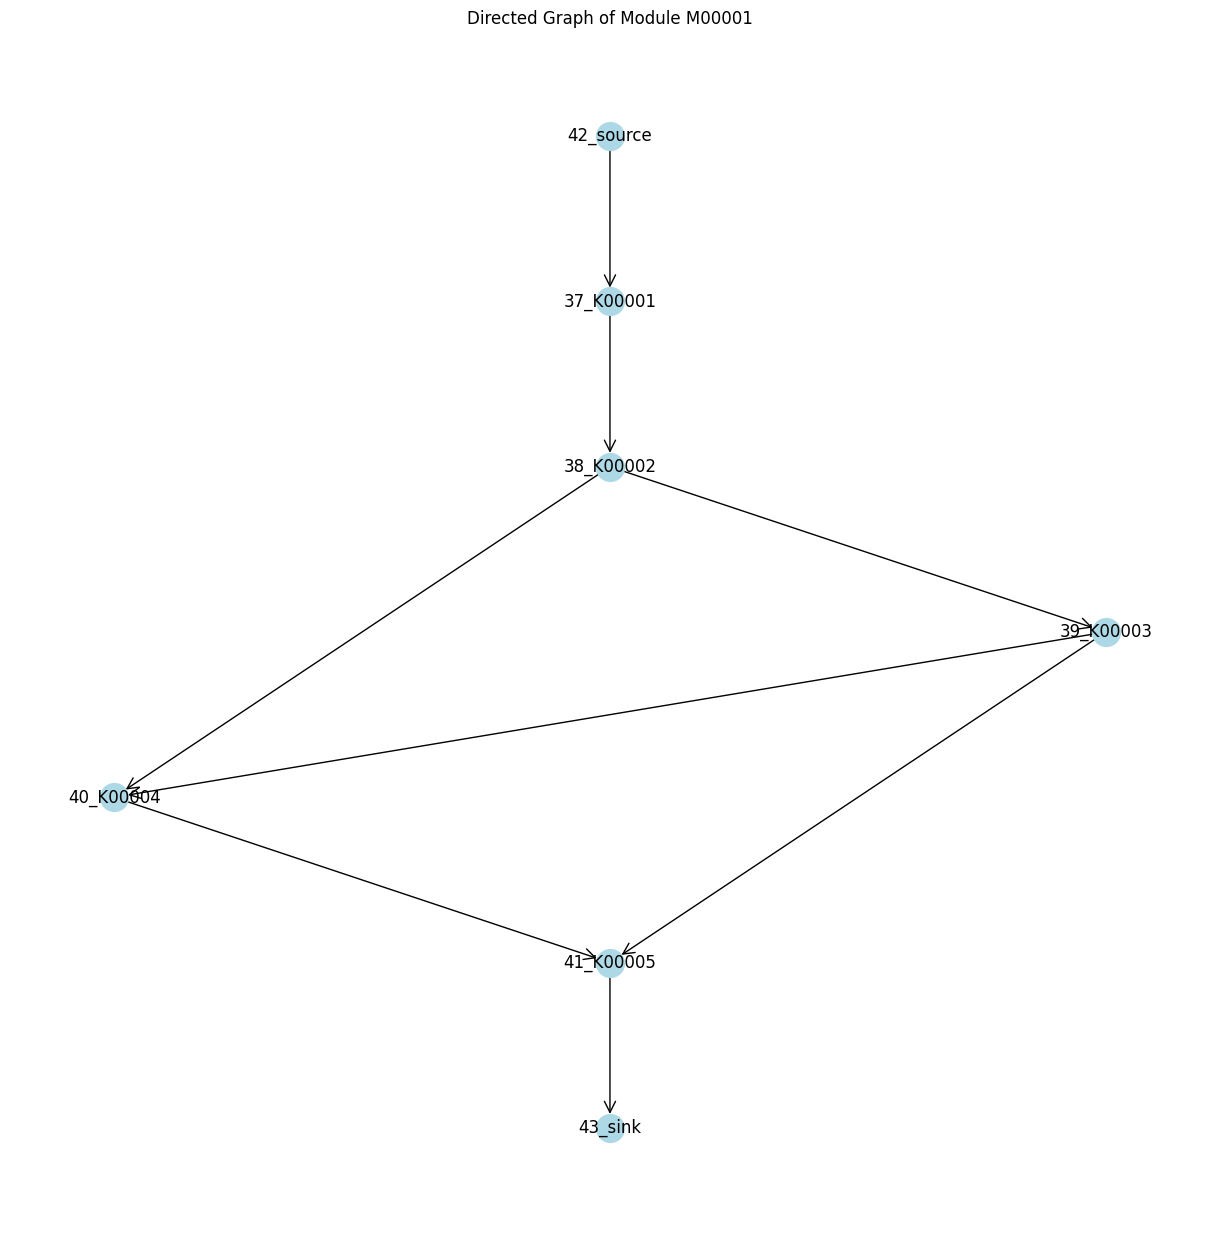

Files for module M00001 already exist. Skipping save.
Graph and adjacency list saved.

Graph Nodes: ['37_K00001', '38_K00002', '39_K00003', '40_K00004', '41_K00005', '42_source', '43_sink']
Graph Edges: [('37_K00001', '38_K00002'), ('38_K00002', '39_K00003'), ('38_K00002', '40_K00004'), ('39_K00003', '40_K00004'), ('39_K00003', '41_K00005'), ('40_K00004', '41_K00005'), ('41_K00005', '43_sink'), ('42_source', '37_K00001')]
--------------------------------------------------


In [ ]:
definition = "(K00001+(K00002+(K00003,K00004)) K00005)"
nodes, edges = build_graph(definition)

# Generate the graph
G = generate_graph(nodes, edges)

# Visualize the graph
visualize_graph(G, module_id)

# Save the graph and adjacency list
save_graph_and_adjacency_list(G, module_id, graph_storage_directory)
print("Graph and adjacency list saved.")

# Display graph nodes and edges
graph_nodes = list(G.nodes())
graph_edges = list(G.edges())
print("\nGraph Nodes:", graph_nodes)
print("Graph Edges:", graph_edges)
print("-" * 50)  # Separator for readabilit